![image.png](attachment:image.png)

## PRACTICA OBLIGATORIA: **Introducción Keras**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

## Descripción de la práctica

En esta práctica el objetivo es jugar con el framework de [Keras](https://www.tensorflow.org/guide/keras) a partir de la construcción de un modelo DL sobre MLP para clasificar imagenes de ropa como camisetas, zapatos y zapatillas deportivas.

Vamos a utilizar el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles)

![image.png](attachment:image.png)

La *class* de ropa que la imagen representa:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset, es recomendable construirse una lista o un diccionario que permita mapear la clase a el tipo literal.

Se pide:

0. Cargar el dataset desde TensorFlow (tienes una celda ya proporcionada para hacerlo) y visualiza al menos 5 instancias, se recomienda crear una función que permita visualizar subsets de instancias con su etiqueta adecuada.

1. Construir un modelo DL basado en MLP, es decir una red densa que clasifique las imágenes de ropa. No vas a necesitar más de 1 o 2 capas ocultas. Recuerda que es un problema de clasificación multiclase para configurar correctamente la capa de salida en número de neuronas y función de activiación. Ten en cuenta también que necesitarás utilizar una capa que aplane las imágenes o bien convertir el dataset por tu cuenta.

2. No crees un set de validación, especifica en el entrenamiento que emplee un 20% del dataset en validación. Además muestra gráficamente la evolución en el entrenamiento de la pérdida (loss) por un lado (del conjuto de train y del de validación) y la evolución de la métrica escogida (también de train  y de validación). Razona si es conveniente tener un "callback" de earlystopping, y, en cualquier caso, implementa uno.

3. Finalmente evalua contra test. Muestra el report de clasificación y haz un análisis de los resultados. Para ello, muestra algunas predicciones, el nivel de confianza y si era acertada o no, además muestra la matriz de confusión y analiza en que tipos se confunde más y con que otra clase lo confunde.

Ejemplo del grafico de predicción más nivel de confianza:

![image.png](attachment:image.png)

Fíjate que el gráfico de la derecha muestra la probabilidad por clase, de forma que cuanto más alta la probabilidad de la clase elegida más confianza podemos decir que tiene en el resultado.

**EXTRA**: Como parte extra, obtén los errores de clasificación en los que la confianza del modelo sobre su clasificación errónea supere el 0.7 o 70% (es decir los errores en los que la probabilidad de la clase elegida, equivocadamente, fuera igual o superior a 0.7), de existir muéstralos y analiza si son de alguna clase específica.

```python

# Cargar FASHION_MNIST

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

```

In [3]:
# Cargar FASHION_MNIST

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Define class names as specified in the problem description
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Number of unique labels: {len(np.unique(train_labels))}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of unique labels: 10


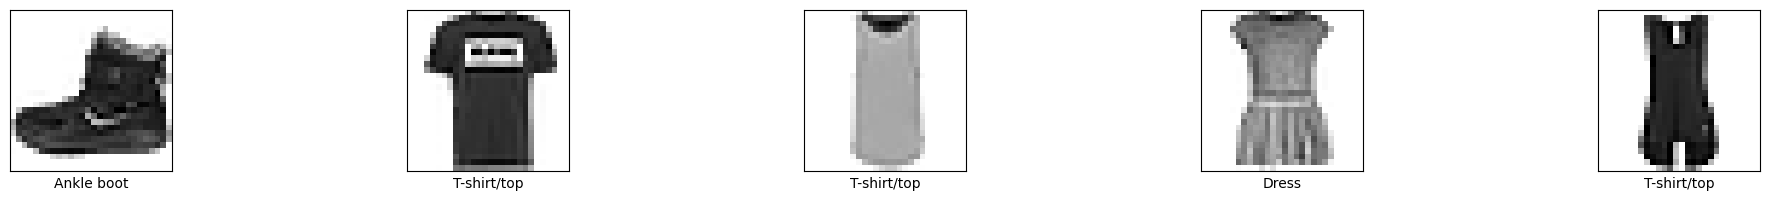

In [4]:
def plot_images(images, labels, predictions=None, num_rows=1, num_cols=5, class_names=class_names):
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(num_rows * num_cols):
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xticks([])
        plt.yticks([])
        if predictions is not None:
            true_label = class_names[labels[i]]
            predicted_label = class_names[np.argmax(predictions[i])]
            color = 'blue' if np.argmax(predictions[i]) == labels[i] else 'red'
            plt.xlabel(f'{predicted_label} ({true_label})',
                       color=color)
        else:
            plt.xlabel(class_names[labels[i]])

        if predictions is not None:
            plt.subplot(num_rows, 2*num_cols, 2*i+2)
            thisplot = plt.bar(range(10), predictions[i], color="#777777")
            plt.ylim([0, 1])
            predicted_label_index = np.argmax(predictions[i])
            true_label_index = labels[i]
            thisplot[predicted_label_index].set_color('red')
            thisplot[true_label_index].set_color('blue')
            plt.xticks(range(10), class_names, rotation=90)
            plt.yticks([])

    plt.tight_layout()
    plt.show()

# Visualizar 5 primeras imágenes de entrenamiento
plot_images(train_images, train_labels, num_rows=1, num_cols=5)

In [5]:
# Normalizar las imágenes a un rango de 0 a 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Verificar el rango de los píxeles después de la normalización
print(f"Rango de píxeles de train_images después de la normalización: {train_images.min()} - {train_images.max()}")

Rango de píxeles de train_images después de la normalización: 0.0 - 1.0


In [6]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Capa para aplanar la imagen
    keras.layers.Dense(128, activation='relu'), # Primera capa oculta con 128 neuronas
    keras.layers.Dense(10, activation='softmax') # Capa de salida con 10 neuronas (una por clase) y activación softmax
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from keras.callbacks import EarlyStopping

# Definir el callback de EarlyStopping
# Monitoreamos la 'val_loss' (pérdida de validación)
# 'patience' es el número de épocas sin mejora después de las cuales se detendrá el entrenamiento
# 'restore_best_weights' asegura que se usen los pesos del modelo con la mejor 'val_loss'
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(train_images, train_labels, epochs=30, # Puedes aumentar o disminuir las épocas iniciales
                    validation_split=0.2, # Usar el 20% de los datos de entrenamiento para validación
                    callbacks=[early_stopping])

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8184 - loss: 0.5199 - val_accuracy: 0.8577 - val_loss: 0.4098
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8609 - loss: 0.3880 - val_accuracy: 0.8482 - val_loss: 0.4107
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8740 - loss: 0.3467 - val_accuracy: 0.8726 - val_loss: 0.3540
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8807 - loss: 0.3243 - val_accuracy: 0.8780 - val_loss: 0.3411
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8884 - loss: 0.3028 - val_accuracy: 0.8786 - val_loss: 0.3394
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8929 - loss: 0.2877 - val_accuracy: 0.8792 - val_loss: 0.3410
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8978 - loss: 0.2728 - val_accuracy: 0.8821 - val_loss: 0.3335
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9040 - loss: 0.26

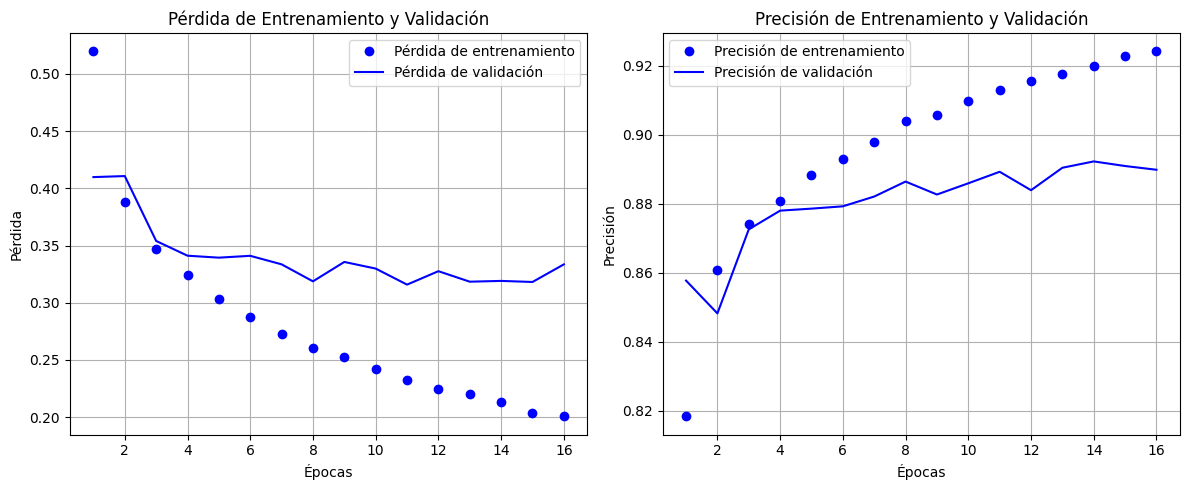

In [8]:
# Obtener los datos del historial de entrenamiento
hist = history.history
loss = hist['loss']
val_loss = hist['val_loss']
accuracy = hist['accuracy']
val_accuracy = hist['val_accuracy']
epochs = range(1, len(loss) + 1)

# Gráfico de pérdida (loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo', label='Pérdida de entrenamiento')
plt.plot(epochs, val_loss, 'b', label='Pérdida de validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'bo', label='Precisión de entrenamiento')
plt.plot(epochs, val_accuracy, 'b', label='Precisión de validación')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en el conjunto de prueba: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.8781 - loss: 0.3470

Precisión en el conjunto de prueba: 0.8781


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Reporte de Clasificación:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.83      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.80      0.74      0.77      1000
       Dress       0.88      0.88      0.88      1000
        Coat       0.77      0.81      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.69      0.71      0.70      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



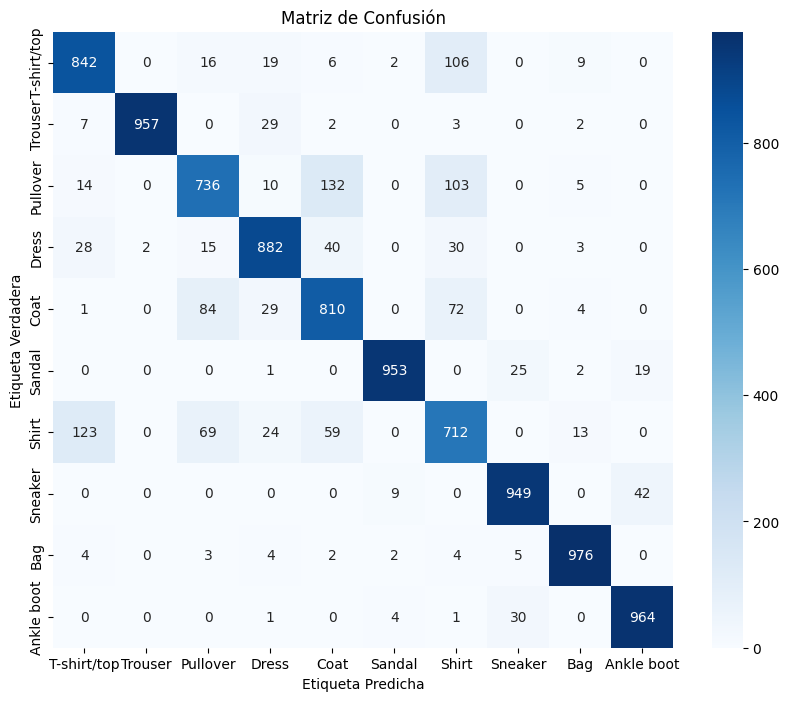

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Realizar predicciones sobre el conjunto de prueba
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Mostrar el reporte de clasificación
print('Reporte de Clasificación:')
print(classification_report(test_labels, predicted_labels, target_names=class_names))

# Mostrar la matriz de confusión
conf_matrix = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

# Análisis de la matriz de confusión:
# Los valores en la diagonal principal representan las clasificaciones correctas.
# Los valores fuera de la diagonal principal representan errores de clasificación.
# Por ejemplo, un valor alto en la fila 'Shirt' y columna 'T-shirt/top' indicaría
# que el modelo confunde mucho las camisetas con las camisas.

In [12]:
# Función para visualizar predicciones (similar a plot_images pero para un solo caso)
def plot_single_prediction(image, true_label, prediction_array, class_names):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(image, cmap=plt.cm.binary)

    predicted_label = np.argmax(prediction_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(prediction_array):2.0f}%) ({class_names[true_label]})",
             color=color)

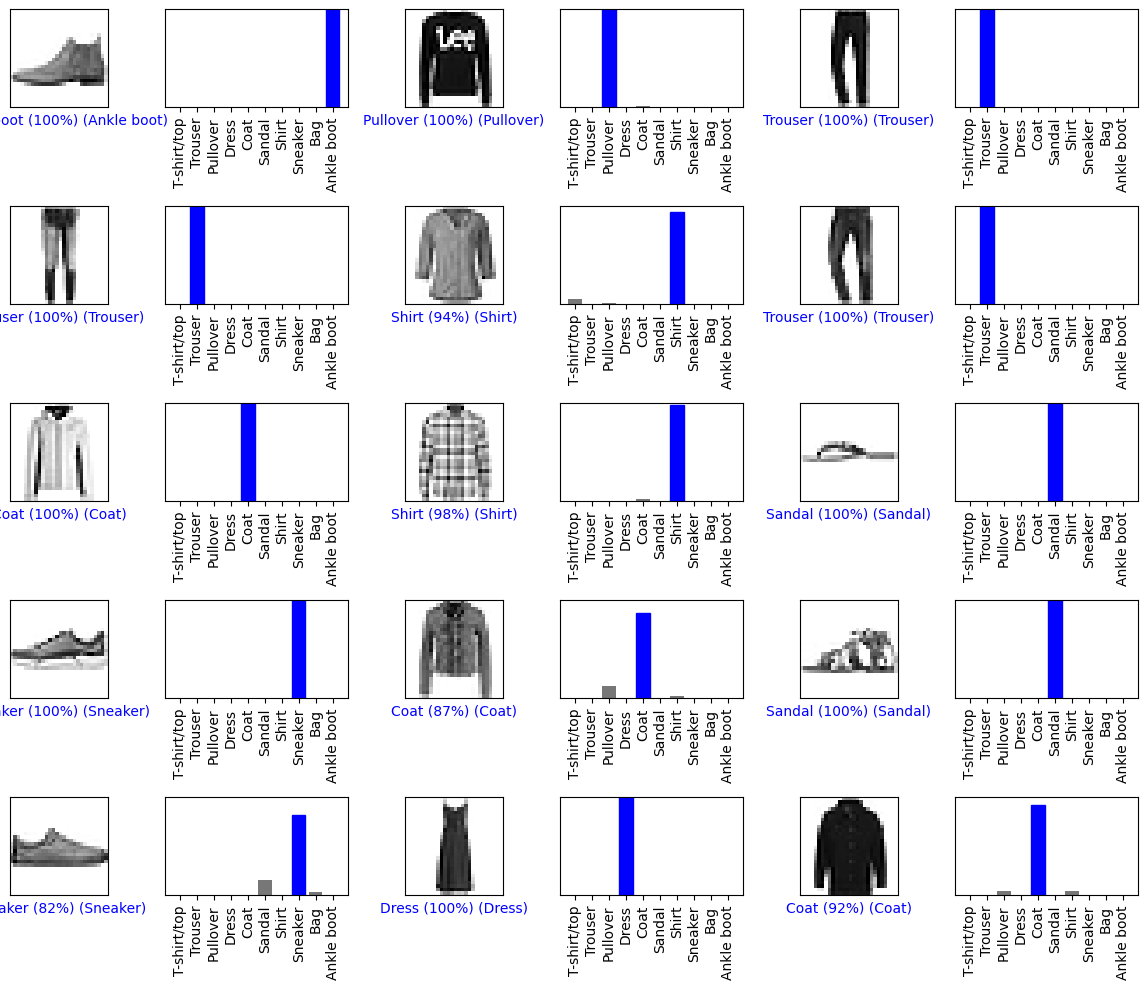

In [14]:
def plot_value_array(prediction_array, true_label, class_names):
    plt.grid(False)
    plt.xticks(range(10), class_names, rotation=90)
    plt.yticks([])
    thisplot = plt.bar(range(10), prediction_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(prediction_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Muestra las primeras 15 predicciones
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_single_prediction(test_images[i], test_labels[i], predictions[i], class_names)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(predictions[i], test_labels[i], class_names)
plt.tight_layout()
plt.show()

Se encontraron 566 errores de clasificación con una confianza superior al 70%:


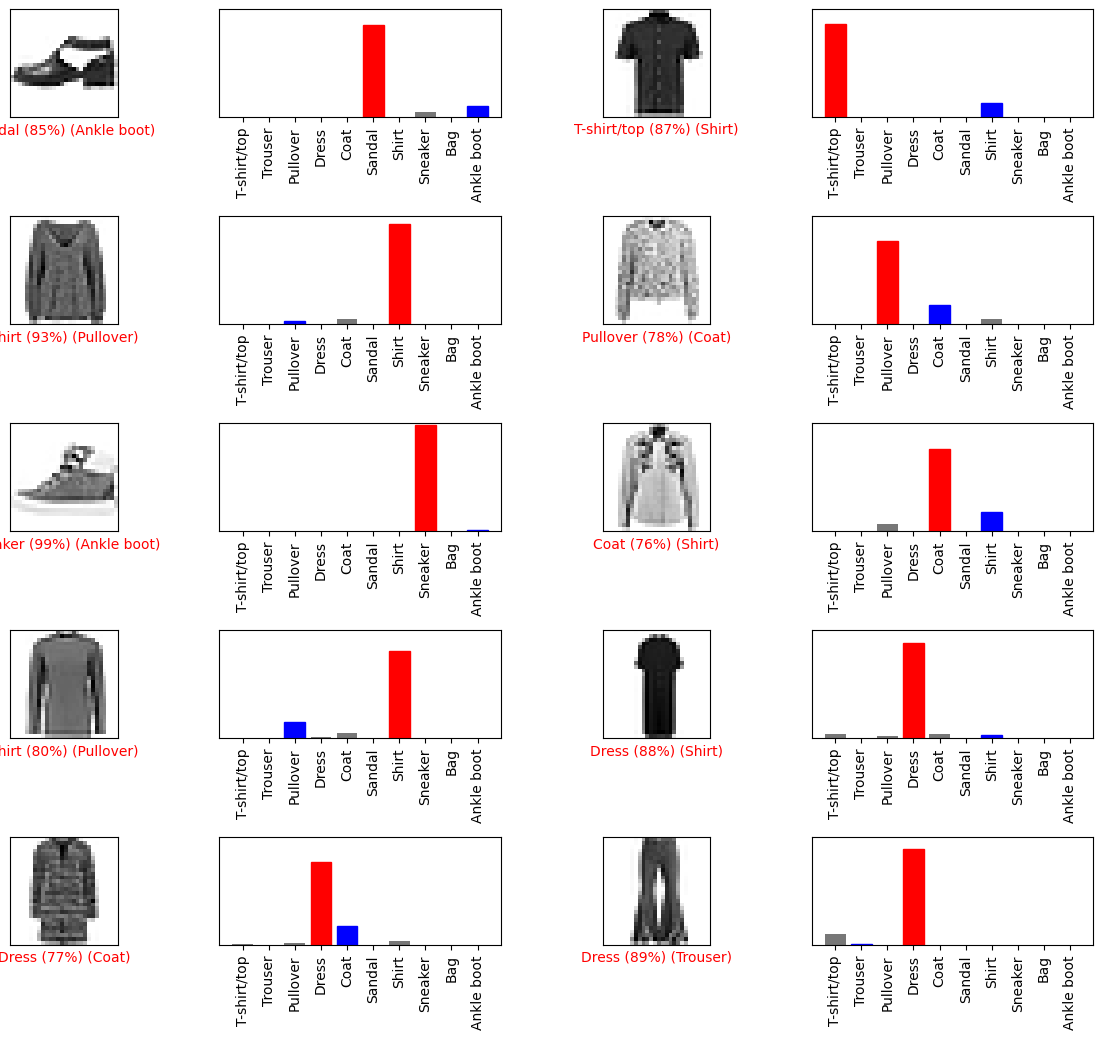


Análisis de los errores con alta confianza:
  Imagen 23: Real 'Ankle boot' pero predijo 'Sandal' con 0.85 de confianza.
  Imagen 40: Real 'Shirt' pero predijo 'T-shirt/top' con 0.87 de confianza.
  Imagen 49: Real 'Pullover' pero predijo 'Shirt' con 0.93 de confianza.
  Imagen 51: Real 'Coat' pero predijo 'Pullover' con 0.78 de confianza.
  Imagen 68: Real 'Ankle boot' pero predijo 'Sneaker' con 0.99 de confianza.
  Imagen 135: Real 'Shirt' pero predijo 'Coat' con 0.76 de confianza.
  Imagen 136: Real 'Pullover' pero predijo 'Shirt' con 0.80 de confianza.
  Imagen 147: Real 'Shirt' pero predijo 'Dress' con 0.88 de confianza.
  Imagen 153: Real 'Coat' pero predijo 'Dress' con 0.77 de confianza.
  Imagen 192: Real 'Trouser' pero predijo 'Dress' con 0.89 de confianza.
  Imagen 227: Real 'Pullover' pero predijo 'Shirt' con 0.81 de confianza.
  Imagen 239: Real 'Coat' pero predijo 'Pullover' con 0.99 de confianza.
  Imagen 244: Real 'Shirt' pero predijo 'Pullover' con 0.92 de confianza.
  

In [15]:
wrong_predictions_high_confidence = []

for i in range(len(test_labels)):
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    max_confidence = np.max(predictions[i])

    if predicted_label != true_label and max_confidence > 0.7:
        wrong_predictions_high_confidence.append({
            'index': i,
            'true_label': true_label,
            'predicted_label': predicted_label,
            'confidence': max_confidence,
            'image': test_images[i],
            'prediction_array': predictions[i]
        })

if len(wrong_predictions_high_confidence) > 0:
    print(f"Se encontraron {len(wrong_predictions_high_confidence)} errores de clasificación con una confianza superior al 70%:")

    num_to_display = min(len(wrong_predictions_high_confidence), 10) # Mostrar hasta 10 de ellos
    plt.figure(figsize=(2*2*3, 2*num_to_display))

    for i, err in enumerate(wrong_predictions_high_confidence[:num_to_display]):
        plt.subplot(num_to_display, 2*2, 2*i+1)
        plot_single_prediction(err['image'], err['true_label'], err['prediction_array'], class_names)
        plt.subplot(num_to_display, 2*2, 2*i+2)
        plot_value_array(err['prediction_array'], err['true_label'], class_names)
    plt.tight_layout()
    plt.show()

    # Análisis de los errores de alta confianza
    if len(wrong_predictions_high_confidence) > 0:
        print("\nAnálisis de los errores con alta confianza:")
        for err in wrong_predictions_high_confidence:
            print(f"  Imagen {err['index']}: Real '{class_names[err['true_label']]}' pero predijo '{class_names[err['predicted_label']]}' con {err['confidence']:.2f} de confianza.")

        # Contar ocurrencias por clase
        true_labels_errors = [err['true_label'] for err in wrong_predictions_high_confidence]
        predicted_labels_errors = [err['predicted_label'] for err in wrong_predictions_high_confidence]

        print("\nClases más frecuentemente mal clasificadas (verdadera):")
        for label in np.unique(true_labels_errors):
            count = true_labels_errors.count(label)
            print(f"  - {class_names[label]}: {count} veces")

        print("\nClases más frecuentemente predichas erróneamente (predicha):")
        for label in np.unique(predicted_labels_errors):
            count = predicted_labels_errors.count(label)
            print(f"  - {class_names[label]}: {count} veces")

else:
    print("No se encontraron errores de clasificación con una confianza superior al 70%.")